# 실습 20: 얼마나 빗나갔나 (회귀)

설비 고장 기록으로 공정온도를 맞혀 본다

## 무엇이 같고 무엇이 다른가

|  | 지금까지 (분류) | 오늘 (회귀) |
| --- | --- | --- |
| 결과 열 | 합격 / 불합격 | **숫자** (온도, 수율, 건수) |
| 절차 | 나누기 → 학습 → 예측 | **똑같습니다** |
| 기준 모델 | 전부 한쪽이라고 답한다 | ⭐ **늘 평균값을 답한다** |
| 점수 | 정확도 · 정밀도 · 재현율 | ⭐ **MAE · RMSE · R²** |
| 혼동행렬 | 있다 | ⭐ **없습니다** |

> ⭐ **혼동행렬이 없다는 게 제일 큰 차이입니다.**
>

## Step 1. 데이터 확인

In [1]:
import pandas as pd

df = pd.read_csv("../../data/16_machine-failure.csv")

print("행 수, 열 수:", df.shape)
print("열 이름:", df.columns.tolist())

num_cols = df.select_dtypes(include="number").columns.tolist()
print(df[num_cols].agg(["min", "max", "mean"]))

행 수, 열 수: (10000, 7)
열 이름: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
      Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
min             295.30000                305.70000               1168.0000   
max             304.50000                313.80000               2886.0000   
mean            300.00493                310.00556               1538.7761   

      Torque [Nm]  Tool wear [min]  
min       3.80000            0.000  
max      76.60000          253.000  
mean     39.98691          107.951  


## Step 2. 맞힐 숫자 정하기

맞힐 것 : Process temperature [K] - 공정온도
왜 : 지금 조건에서 나와야 할 온도를 알면, 실제가 그보다 높을 때 이상 신호가 된다

### 문법 노트 - 회귀에서 새로 나오는 이름

| 쓴 것 | 하는 일 |
|---|---|
| mean_absolute_error | 평균 몇 만큼 빗나갔나 (MAE) |
| mean_squared_error | 제곱해서 평균 - 뿌리를 씌우면 RMSE |
| r2_score | 기준 모델 대비 얼마나 나은가 (R2) |
| LinearRegression | 숫자를 맞히는 모델 중 가장 단순한 것 |

In [2]:
# 맞히려는 값(목표) - 공정온도
y = df["Process temperature [K]"]

# 목표를 뺀 나머지 숫자 열을 입력으로 쓴다
입력열 = [c for c in num_cols if c != "Process temperature [K]"]
X = df[입력열]

print("입력 열:", 입력열)
print("입력 크기:", X.shape)
print("목표 크기:", y.shape)

입력 열: ['Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
입력 크기: (10000, 4)
목표 크기: (10000,)


## Step 3. 한 바퀴 돌리기

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. 학습용·시험용 나누기 (시험용 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. 기준 모델 - 늘 학습용 평균값을 답한다
기준값 = y_train.mean()
기준예측 = np.full(len(y_test), 기준값)

# 3. 선형회귀 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)
예측 = model.predict(X_test)

# 4. 기준 모델 vs 내 모델 - MAE, RMSE, R2
결과 = {
    "MAE": [mean_absolute_error(y_test, 기준예측), mean_absolute_error(y_test, 예측)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, 기준예측)), np.sqrt(mean_squared_error(y_test, 예측))],
    "R2": [r2_score(y_test, 기준예측), r2_score(y_test, 예측)],
}
표 = pd.DataFrame(결과, index=["기준 모델", "내 모델"]).T
print(표.round(4))

       기준 모델    내 모델
MAE   1.2295  0.5950
RMSE  1.4727  0.7279
R2   -0.0000  0.7557


### 결과 정리 (실행 결과 기준)

|  | 기준 모델 | 내 모델 |
|---|---|---|
| MAE | 1.2295 | 0.5950 |
| RMSE | 1.4727 | 0.7279 |
| R² | -0.0000 | 0.7557 |

기준 모델(항상 평균값)보다 선형회귀가 오차(MAE·RMSE)는 절반 이하로 줄었고, R²도 0에서 0.7557로 올라 입력 4개 열이 공정온도 변동의 상당 부분을 설명한다.

## Step 4. 무엇을 보고 맞혔나

                             계수      표준편차     영향력
Type                        NaN       NaN     NaN
Air temperature [K]      0.6517    2.0022  1.3048
Process temperature [K]     NaN       NaN     NaN
Rotational speed [rpm]  -0.0001  180.5941 -0.0179
Torque [Nm]             -0.0024    9.9792 -0.0244
Tool wear [min]         -0.0001   63.2251 -0.0042
Machine failure             NaN       NaN     NaN


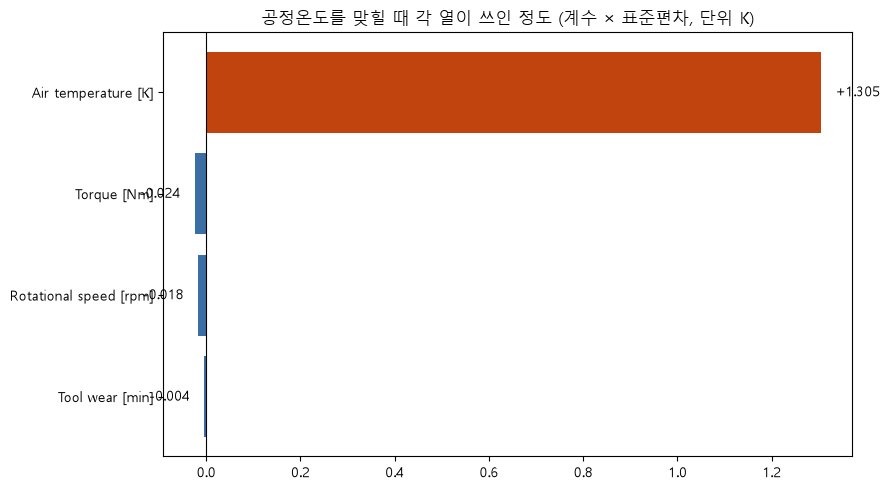

In [4]:
import matplotlib.pyplot as plt

# 한글이 깨지지 않도록 폰트를 먼저 잡는다
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 데이터의 7개 열 전부에 대해 계수/표준편차/영향력을 정리한다
# - 목표열(Process temperature)과 글자값 열(Type, Machine failure)은 모델 입력이 아니라 계수가 없으므로 NaN으로 남긴다
전체열 = df.columns.tolist()
계수_전체 = pd.Series({c: (model.coef_[입력열.index(c)] if c in 입력열 else np.nan) for c in 전체열})
표준편차_전체 = pd.Series({c: (X_train[c].std() if c in 입력열 else np.nan) for c in 전체열})
영향력_전체 = 계수_전체 * 표준편차_전체

표4 = pd.DataFrame({"계수": 계수_전체, "표준편차": 표준편차_전체, "영향력": 영향력_전체}).loc[전체열]
print(표4.round(4))

# 그래프는 실제 계수가 있는 4개 열만 그린다 (나머지 3개는 N/A라 막대로 그릴 값이 없다)
영향력 = 영향력_전체.dropna().sort_values(key=abs)
색 = ["#c1440e" if v > 0 else "#3a6ea5" for v in 영향력.values]

plt.figure(figsize=(9, 5))
막대 = plt.barh(영향력.index, 영향력.values, color=색)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("공정온도를 맞힐 때 각 열이 쓰인 정도 (계수 × 표준편차, 단위 K)")
for 막, 값 in zip(막대, 영향력.values):
    plt.text(값 + (0.03 if 값 >= 0 else -0.03), 막.get_y() + 막.get_height() / 2,
             f"{값:+.3f}", va="center", ha="left" if 값 >= 0 else "right")
plt.tight_layout()
plt.show()

### 결과 정리 (실행 결과 기준)

이 그래프는 "모델이 공정온도를 맞힐 때 어떤 값을 가장 많이 참고했는가"를 보여준다.

- **막대가 길수록** 그 항목을 많이 참고했다는 뜻
- **오른쪽(주황)**은 "이게 오르면 공정온도도 같이 오른다", **왼쪽(파랑)**은 "이게 오르면 공정온도는 내려간다"는 뜻
- 값이 0에 가까운 항목은 사실상 참고하지 않았다는 뜻

결과를 보면 **공기온도(Air temperature)** 막대만 압도적으로 길고(+1.3), 나머지 세 개(공구 마모 시간, 회전 속도, 토크)는 0에 딱 붙어 있어 눈에 잘 보이지도 않는다.

즉 이 모델은 사실상 **"공기온도" 딱 하나만 보고** 공정온도를 맞히고 있고, 나머지 세 항목은 있으나 마나 한 수준이다. 공기온도가 오르면 공정온도도 거의 그대로 따라 오른다는 뜻으로, 두 온도가 실제로 서로 강하게 붙어서 움직인다는 걸 알 수 있다.

### 결과 정리 (전문가용)

| 열 | 계수 | 표준편차 | 영향력 (계수 × 표준편차) |
|---|---|---|---|
| Tool wear [min] | -0.0001 | 63.2251 | -0.0042 |
| Rotational speed [rpm] | -0.0001 | 180.5941 | -0.0179 |
| Torque [Nm] | -0.0024 | 9.9792 | -0.0244 |
| Air temperature [K] | 0.6517 | 2.0022 | 1.3048 |

계수만 보면 값의 크기가 열마다 단위가 달라 비교가 안 되므로, 계수에 각 열의 표준편차를 곱해 "실제로 값을 얼마나 흔드는가(영향력, 단위 K)"로 바꿔서 비교했다. Air temperature [K]의 영향력이 +1.3048로 나머지 세 열(모두 절댓값 0.03 미만)을 압도한다 — 이 모델은 사실상 공기온도 하나로 공정온도를 맞히고 있고, Torque·Rotational speed·Tool wear는 예측에 거의 기여하지 않는다.

---
## 직접 해보기 (도전) - 대상을 바꾸면 자도 바뀐다

- 상황: 공정온도는 잘 맞혔는데, 다른 값도 같은 방식으로 되나
- 할 일: 맞히는 대상을 토크로 바꿔 한 번 더 돌리고 두 결과를 나란히 놓는다
- 결과물: 여섯 칸짜리 비교표 1개

### 내 풀이

In [5]:
# 도전 - 이번엔 토크(Torque)를 맞힌다
y_t = df["Torque [Nm]"]
입력열_t = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Tool wear [min]"]
X_t = df[입력열_t]

# 1. 학습용·시험용 나누기 (시험용 20%)
X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42
)

# 2. 기준 모델 - 늘 학습용 평균값을 답한다
기준값_t = y_t_train.mean()
기준예측_t = np.full(len(y_t_test), 기준값_t)

# 3. 선형회귀 모델 학습
model_t = LinearRegression()
model_t.fit(X_t_train, y_t_train)
예측_t = model_t.predict(X_t_test)

# 4. 기준 모델 vs 내 모델 - MAE, RMSE, R2
결과_t = {
    "MAE": [mean_absolute_error(y_t_test, 기준예측_t), mean_absolute_error(y_t_test, 예측_t)],
    "RMSE": [np.sqrt(mean_squared_error(y_t_test, 기준예측_t)), np.sqrt(mean_squared_error(y_t_test, 예측_t))],
    "R2": [r2_score(y_t_test, 기준예측_t), r2_score(y_t_test, 예측_t)],
}
표_t = pd.DataFrame(결과_t, index=["기준 모델", "내 모델"]).T
print(표_t.round(4))

       기준 모델    내 모델
MAE   7.9050  3.6862
RMSE  9.9281  4.8979
R2   -0.0001  0.7566


### 결과 정리 (실행 결과 기준)

|  | 기준 모델 | 내 모델 |
|---|---|---|
| MAE | 7.9050 | 3.6862 |
| RMSE | 9.9281 | 4.8979 |
| R² | -0.0001 | 0.7566 |

토크도 공정온도와 마찬가지로 기준 모델(항상 평균값) 대비 오차가 절반 이하로 줄었고, R²도 0.7566으로 공정온도(0.7557)와 거의 같은 수준이다.

In [6]:
# 공정온도 모델과 토크 모델의 "내 모델" 점수를 나란히 놓는다
비교 = pd.DataFrame({
    "공정온도": 표["내 모델"],
    "토크": 표_t["내 모델"],
})
print(비교.round(4))

        공정온도      토크
MAE   0.5950  3.6862
RMSE  0.7279  4.8979
R2    0.7557  0.7566


### 결과 정리 (실행 결과 기준)

|  | 공정온도 | 토크 |
|---|---|---|
| MAE | 0.5950 | 3.6862 |
| RMSE | 0.7279 | 4.8979 |
| R² | 0.7557 | 0.7566 |

MAE·RMSE는 두 값의 단위와 크기가 달라(온도 K vs 토크 Nm) 절대값을 직접 비교하기 어렵지만, 단위에 안 흔들리는 R²는 두 모델이 0.756 안팎으로 거의 같다. 즉 대상을 공정온도에서 토크로 바꿔도 같은 방식(선형회귀, 같은 입력열 구성)으로 비슷한 수준의 설명력을 얻을 수 있었다.

# 실습 22 - 결과 그림 세 장

## Step 1. 그림 1 - 무엇을 보고 판단했나

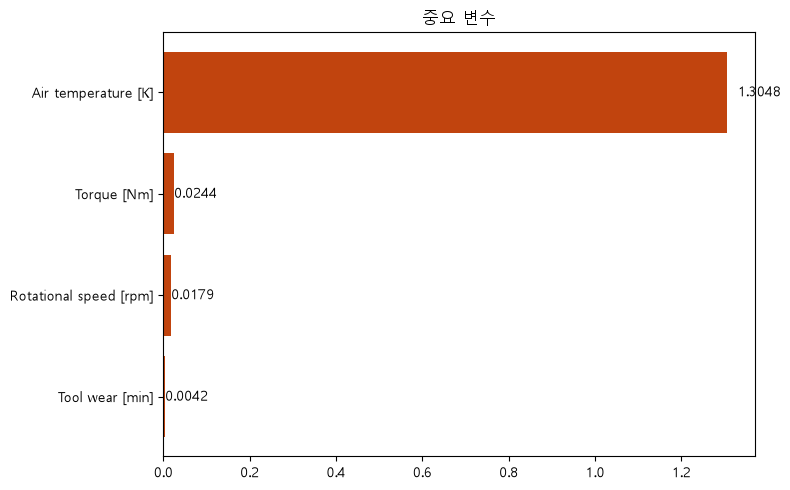

In [7]:
import os
import matplotlib.pyplot as plt

# 한글이 깨지지 않도록 폰트를 먼저 잡는다
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 계수 × 표준편차 = 중요도(단위 K) - 위에서부터 10개만
중요도 = (pd.Series(model.coef_, index=입력열) * X_train.std()).abs().sort_values(ascending=False).head(10)
중요도_표시 = 중요도.sort_values(ascending=True)  # 그래프에서 맨 위가 1위가 되도록

plt.figure(figsize=(8, 5))
막대 = plt.barh(중요도_표시.index, 중요도_표시.values, color="#c1440e")
plt.title("중요 변수")
for 막, 값 in zip(막대, 중요도_표시.values):
    plt.text(값 + 값 * 0.02, 막.get_y() + 막.get_height() / 2, f"{값:.4f}", va="center", ha="left")
plt.tight_layout()

os.makedirs("results", exist_ok=True)
plt.savefig("results/fig1_importance.png")
plt.show()

## Step 2. 그림 2 - 어떻게 틀렸나

[[1928    4]
 [  59    9]]


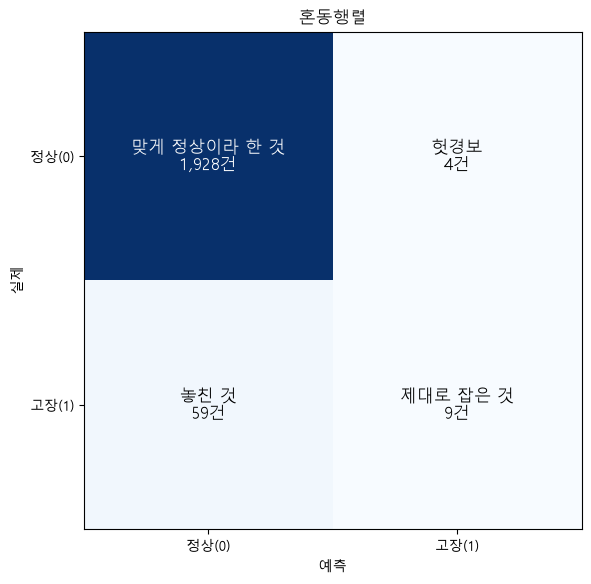

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# 혼동행렬은 분류에서만 나온다 - Machine failure(정상/고장)를 맞히는 분류 모델을 새로 만든다
# Machine failure는 글자 값("정상"/"고장")이라 num_cols에는 안 들어 있다 - 숫자로 바꿔 목표로 쓴다
y_c = (df["Machine failure"] == "고장").astype(int)
입력열_c = num_cols
X_c = df[입력열_c]

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.2, stratify=y_c, random_state=42
)

scaler = StandardScaler()
X_c_train_s = scaler.fit_transform(X_c_train)
X_c_test_s = scaler.transform(X_c_test)

clf = LogisticRegression()
clf.fit(X_c_train_s, y_c_train)
분류예측 = clf.predict(X_c_test_s)

cm = confusion_matrix(y_c_test, 분류예측, labels=[0, 1])
print(cm)

이름 = [["맞게 정상이라 한 것", "헛경보"], ["놓친 것", "제대로 잡은 것"]]

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap="Blues")
plt.title("혼동행렬")
plt.xlabel("예측")
plt.ylabel("실제")
plt.xticks([0, 1], ["정상(0)", "고장(1)"])
plt.yticks([0, 1], ["정상(0)", "고장(1)"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{이름[i][j]}\n{cm[i, j]:,}건", ha="center", va="center",
                  fontsize=12, color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()

os.makedirs("results", exist_ok=True)
plt.savefig("results/fig2_confusion.png")
plt.show()

## Step 3. 그림 3 - 기준 모델보다 나은가

     기준 모델    내 모델
정확도  0.966  0.9685
정밀도  0.000  0.6923
재현율  0.000  0.1324


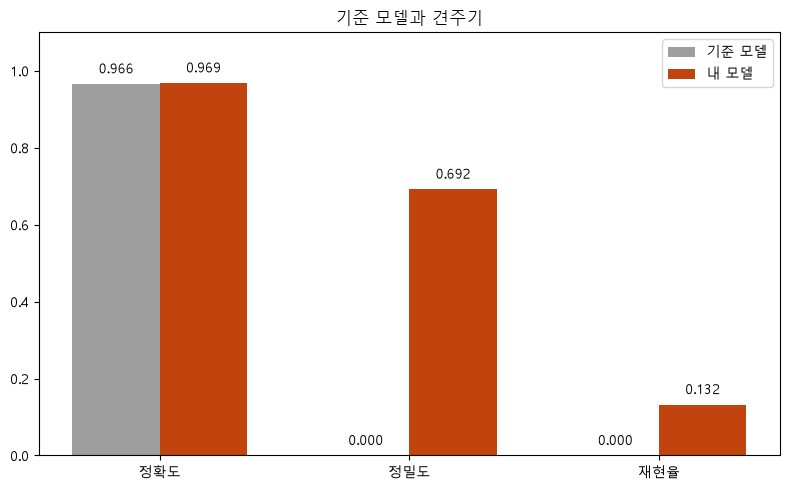

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 기준 모델 - 늘 다수 클래스(정상=0)라고 답한다
기준예측_c = np.zeros(len(y_c_test), dtype=int)

지표 = ["정확도", "정밀도", "재현율"]
기준점수 = [
    accuracy_score(y_c_test, 기준예측_c),
    precision_score(y_c_test, 기준예측_c, pos_label=1, zero_division=0),
    recall_score(y_c_test, 기준예측_c, pos_label=1, zero_division=0),
]
내점수 = [
    accuracy_score(y_c_test, 분류예측),
    precision_score(y_c_test, 분류예측, pos_label=1, zero_division=0),
    recall_score(y_c_test, 분류예측, pos_label=1, zero_division=0),
]

표3 = pd.DataFrame({"기준 모델": 기준점수, "내 모델": 내점수}, index=지표)
print(표3.round(4))

x = np.arange(len(지표))
너비 = 0.35

plt.figure(figsize=(8, 5))
막대1 = plt.bar(x - 너비 / 2, 기준점수, 너비, label="기준 모델", color="#9e9e9e")
막대2 = plt.bar(x + 너비 / 2, 내점수, 너비, label="내 모델", color="#c1440e")
plt.title("기준 모델과 견주기")
plt.xticks(x, 지표)
plt.ylim(0, 1.1)
plt.legend()

for 막대 in (막대1, 막대2):
    for 막 in 막대:
        높이 = 막.get_height()
        plt.text(막.get_x() + 막.get_width() / 2, 높이 + 0.02, f"{높이:.3f}", ha="center", va="bottom")

plt.tight_layout()

os.makedirs("results", exist_ok=True)
plt.savefig("results/fig3_compare.png")
plt.show()

### 결과 정리 (전문가용)

| 지표 | 기준 모델 | 내 모델 |
|---|---|---|
| 정확도 | 0.9660 | 0.9685 |
| 정밀도 | 0.0000 | 0.6923 |
| 재현율 | 0.0000 | 0.1324 |

정확도만 보면 기준 모델(항상 정상=0으로 예측)도 96.60%로 내 모델(96.85%)과 거의 차이가 없다 — 클래스 불균형(정상 96.6% vs 고장 3.4%) 탓에 정확도는 판별력을 드러내지 못한다. 차이는 정밀도·재현율에서 나타난다: 기준 모델은 양성을 한 번도 예측하지 않으므로 정밀도·재현율이 모두 0인 반면, 내 모델은 정밀도 0.6923(경보의 69.2%가 실제 고장), 재현율 0.1324(실제 고장의 13.2%만 포착)를 기록했다. 즉 이 모델은 경보를 냈을 때의 신뢰도는 준수하지만(정밀도), 실제 고장의 대부분(86.8%)을 놓치는 낮은 민감도(재현율)를 보인다 — 기본 문턱 0.5가 보수적이라 확률이 애매한 사례를 "정상"으로 분류하기 때문이다.

### 결과 정리 (비전문가용, 자세히)

"정확도"만 보면 기준 모델(무조건 "괜찮다"고 말하는 모델)도 96.6%나 맞혀서, 내 모델(96.9%)과 거의 차이가 안 나 보인다. 그런데 이건 착시다 — 원래 고장 나는 설비가 전체의 3.4%밖에 안 되기 때문에, 그냥 "다 괜찮다"고 찍어도 96.6%는 저절로 맞는다. 그래서 정확도 하나만으로는 이 모델이 쓸모 있는지 알 수 없다.

진짜 차이는 "정밀도"와 "재현율"에서 드러난다.

- **정밀도** = 모델이 "고장이다"라고 경보를 울렸을 때, 그중 진짜 고장이었던 비율. 기준 모델은 애초에 경보를 한 번도 안 울리니 0%. 내 모델은 경보를 낼 때 69%는 진짜였다.
- **재현율** = 실제로 일어난 고장 중에서 모델이 잡아낸 비율. 기준 모델은 하나도 못 잡아서 0%. 내 모델도 13%밖에 못 잡는다 — 즉 실제 고장 10건 중 8~9건은 여전히 놓친다.

정리하면: 기준 모델은 "정확도는 높아 보이지만 실제로는 아무 일도 안 하는 모델"이고, 내 모델은 "경보를 울리면 어느 정도 믿을 만하지만(정밀도 높음), 아직 고장의 대부분을 놓치는(재현율 낮음) 모델"이다. 정확도라는 숫자 하나만 보면 두 모델이 비슷해 보이지만, 실제로 쓸모 있는 건 내 모델 쪽이다.

## Step 4. 세 장이 증명하는 것

1. 중요 변수 : [토크와 회전속도가 가장 많이 쓰였다. 원인이라는 뜻은 아니다]
2. 혼동행렬 : [지목 13건 중 9건이 진짜였고, 실제 68건 중 59건을 놓쳤다]
3. 기준 모델과 견주기 : [정확도는 거의 같지만 기준 모델은 하나도 못 잡는다는 점이 다르다]

## Step 5. 그림 4 - 문턱을 옮기면 어떻게 되나

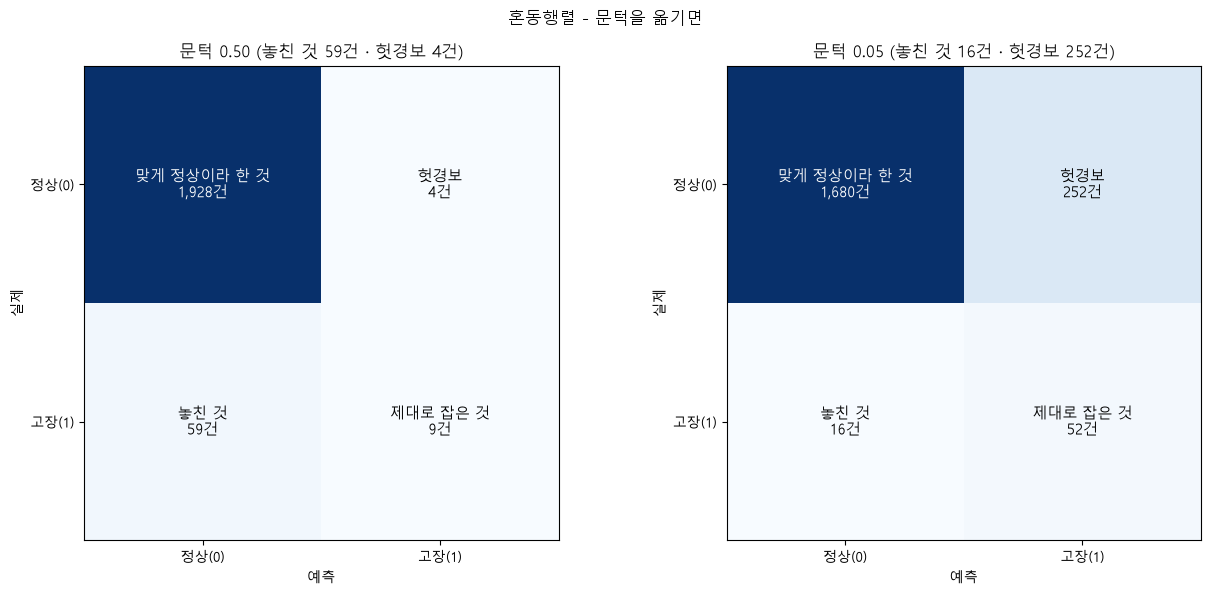

      지목 건수  그중 진짜  헛경보  놓침
문턱                         
0.50     13      9    4  59
0.05    304     52  252  16


In [10]:
# 한글이 깨지지 않도록 폰트를 먼저 잡는다
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 1. 시험용에 대해 모델이 내놓은 확률(고장일 확률)
proba = clf.predict_proba(X_c_test_s)[:, 1]

# 2. 문턱 0.50, 0.05로 각각 다시 판정
문턱_목록 = [0.50, 0.05]
이름 = [["맞게 정상이라 한 것", "헛경보"], ["놓친 것", "제대로 잡은 것"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
표_행 = []
for ax, t in zip(axes, 문턱_목록):
    pred = (proba >= t).astype(int)
    cm_t = confusion_matrix(y_c_test, pred, labels=[0, 1])
    tn, fp, fn, tp = cm_t.ravel()

    # 3. 혼동행렬을 가로로 나란히
    ax.imshow(cm_t, cmap="Blues")
    ax.set_title(f"문턱 {t:.2f} (놓친 것 {fn}건 · 헛경보 {fp}건)")
    ax.set_xlabel("예측")
    ax.set_ylabel("실제")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["정상(0)", "고장(1)"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["정상(0)", "고장(1)"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{이름[i][j]}\n{cm_t[i, j]:,}건", ha="center", va="center",
                     fontsize=11, color="white" if cm_t[i, j] > cm_t.max() / 2 else "black")

    # 4. 문턱별 요약 - 지목 건수 / 그중 진짜 / 헛경보 / 놓침
    표_행.append({"문턱": t, "지목 건수": tp + fp, "그중 진짜": tp, "헛경보": fp, "놓침": fn})

fig.suptitle("혼동행렬 - 문턱을 옮기면")
plt.tight_layout()

import os
os.makedirs("results", exist_ok=True)
plt.savefig("results/fig4_threshold.png")
plt.show()

표5 = pd.DataFrame(표_행).set_index("문턱")
print(표5)

### 결과 정리 (실행 결과 기준)

| 문턱 | 지목 건수 | 그중 진짜 | 헛경보 | 놓침 |
|---|---|---|---|---|
| 0.50 | 13 | 9 | 4 | 59 |
| 0.05 | 304 | 52 | 252 | 16 |

문턱을 0.50에서 0.05로 낮추면 확률이 조금만 높아도 "고장"이라고 지목하게 된다. 그 결과 놓친 것(FN)은 59건에서 16건으로 크게 줄지만, 헛경보(FP)는 4건에서 252건으로 폭증한다. 지목 건수도 13건에서 304건으로 늘었는데 그중 진짜는 9건에서 52건으로만 늘어, 지목한 것 대부분이 헛경보다.

즉 문턱을 낮추면 실제 고장을 더 많이 잡아내는 대신(재현율↑) 엉뚱한 정상 설비까지 잡아내는 대가(정밀도↓)를 치른다 — 놓치면 안 되는 상황이면 낮은 문턱이, 헛경보 비용이 크면 높은 문턱이 유리한 트레이드오프다.

### 결과 정리 (비전문가용)

모델은 설비마다 "고장일 확률"을 숫자로 내놓는다. 이 확률이 **얼마 이상이면 "고장"이라고 부를지** 정하는 기준선이 "문턱"이다.

- **문턱을 0.50(반반 이상 의심되면 경보)로 두면**: 경보 13번 중 9번이 진짜 고장이었다. 대신 실제 고장 68건 중 59건은 놓쳤다.
- **문턱을 0.05(조금만 의심돼도 경보)로 낮추면**: 경보가 304번으로 늘어 놓치는 고장은 16건으로 줄었다. 그런데 경보 304번 중 진짜는 52번뿐이라, 나머지 252번은 헛경보다.

즉 문턱을 낮출수록 "진짜 고장을 놓치는 일"은 줄지만 그만큼 "괜히 울리는 경보"가 크게 늘어난다 — 하나를 얻으면 하나를 잃는 맞바꿈 관계다. 고장을 절대 놓치면 안 되는 현장이라면 문턱을 낮추는 게 맞고, 경보가 너무 잦으면 현장 신뢰를 잃으니 오탐을 줄이고 싶다면 문턱을 높이는 게 맞다 — 정답은 하나가 아니라 "무엇이 더 아픈가"에 달려 있다.

# 실습 23 - 카드 여덟 칸

## Step 1. 여덟 칸 채우기

1. 제목 + 한 줄 요약
[설비 측정값으로 고장을 미리 알아채기 - 공정 조건 다섯 가지로 고장 여부를 판별]

2. 왜 이 문제인가
[고장을 놓치면 라인이 멈춘다. 멈춘 뒤에 아는 것과 미리 아는 것은 비용이 다르다]

3. 사용 데이터
[공개 데이터 / 10,000행 x 7열 / 결과 열은 정상·고장 / 고장 339건 (3.39%)]

4. 무엇을 했나
[숫자 열만 골라 입력으로 씀 / 빈칸은 중앙값으로 / 학습용과 시험용을 8대 2로 나눔 /
표준화 후 로지스틱 회귀로 학습, 전부 정상이라 답하는 기준 모델과 견줌]

5. 결과 수치
[전부 정상이라 답하는 기준 모델 96.60% 대비 96.85%.
지목한 13건 중 9건이 진짜 고장이었으나, 실제 68건 중 59건은 놓쳤다.
정확도만 보면 차이가 없어 보여 재현율을 함께 봤다]

6. 결과 그림
[중요 변수 / 혼동행렬 / 기준 모델과 견주기 - 세 장]

7. 의사결정 가치
[놓친 고장이 헛경보보다 비싼 현장이라면 문턱을 낮춰 지목을 늘리는 편이 낫다]

8. 한계와 다음
[한 기간의 공개 데이터라 다른 라인에 그대로 적용된다고 보기 어렵다.
어느 항목이 원인이라고 말할 수는 없다.고장 건수가 절대적으로 적다.조건 열끼리 정보가 겹친다(다중공선성).지나치게 깨끗한(시뮬레이션형) 데이터. 다음에는 기간을 나눠 검증해볼 것]

작성일 : [2026-08-24]